# Convolutional Autoencoder with Residual Learning Training

## Objective

Train a residual convolutional autoencoder for 2× image super-resolution.

Unlike the previous autoencoder, this model learns only the residual image that must be added to the bicubic interpolation.

The notebook includes:

- model initialization
- DataLoader creation
- loss definition
- optimizer
- scheduler
- training loop
- validation
- checkpoint saving
- training curves

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [2]:
import torch

from src.models.autoencoder_residual import ConvAutoencoderResidual

from src.dataloader import (
    get_train_loader,
    get_validation_loader
)

from src.train import train_one_epoch
from src.evaluate import evaluate

from src.losses import CombinedLoss
from src.losses import PerceptualLoss

from src.config import LEARNING_RATE

## Device

Select the device used for training.

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


## DataLoader

In [4]:
train_loader = get_train_loader()
valid_loader = get_validation_loader()

## Model

In [5]:
model = ConvAutoencoderResidual().to(device)

print(model)

ConvAutoencoderResidual(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
  )
  (bottleneck): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1

## Loss Function

In [6]:
pixel_loss = CombinedLoss(
    edge_weight=0.20
)

perceptual_loss = PerceptualLoss()

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\aless/.cache\torch\hub\checkpoints\vgg16-397923af.pth
100%|██████████| 528M/528M [01:09<00:00, 7.94MB/s] 


In [7]:
def criterion(output, target):

    loss_pixel = pixel_loss(
        output,
        target
    )

    loss_perceptual = perceptual_loss(
        output,
        target
    )

    return (
        loss_pixel
        +
        0.05 * loss_perceptual
    )

## Optimizer

In [8]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-5
)

In [9]:
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=50,
    gamma=0.5
)

## Training

In [10]:
from src.checkpoint import load_model
from src.models.autoencoder_residual import ConvAutoencoderResidual

model = ConvAutoencoderResidual().to(device)

model = load_model(
    model,
    "../results/checkpoints/autoencoder_residual_best.pth",
    device
)

print("Best model loaded.")

Best model loaded.


c:\Users\aless\Documents\RetroSR-CNN\src\checkpoint.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(filepath, map_location=device)


In [11]:
from src.checkpoint import save_model

TRAIN_EPOCHS = 25

loss_history = []
best_psnr = 0.0

patience = 20
epochs_without_improvement = 0

train_loss_history = []
valid_loss_history = []
valid_psnr_history = []

for epoch in range(TRAIN_EPOCHS):

    train_loss = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    valid_loss, valid_psnr = evaluate(
        model=model,
        dataloader=valid_loader,
        criterion=criterion,
        device=device
    )

    train_loss_history.append(train_loss)
    valid_loss_history.append(valid_loss)
    valid_psnr_history.append(valid_psnr)

    print(
        f"Epoch {epoch+1}/{TRAIN_EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Valid Loss: {valid_loss:.6f} | "
        f"PSNR: {valid_psnr:.2f} dB | "
        f"LR: {optimizer.param_groups[0]['lr']:.6f}"
    )

    if valid_psnr > best_psnr:

        best_psnr = valid_psnr

        epochs_without_improvement = 0

        save_model(
            model,
            "../results/checkpoints/autoencoder_residual_perceptual_best.pth"
    )

        print("Best model saved!")

    else:

        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:

        print("\nEarly stopping activated!")

        break

    scheduler.step()

Epoch 1/25 | Train Loss: 0.037293 | Valid Loss: 0.039138 | PSNR: 30.61 dB | LR: 0.000010
Best model saved!
Epoch 2/25 | Train Loss: 0.036935 | Valid Loss: 0.034744 | PSNR: 31.21 dB | LR: 0.000010
Best model saved!
Epoch 3/25 | Train Loss: 0.036176 | Valid Loss: 0.036204 | PSNR: 31.62 dB | LR: 0.000010
Best model saved!
Epoch 4/25 | Train Loss: 0.037034 | Valid Loss: 0.037509 | PSNR: 30.76 dB | LR: 0.000010
Epoch 5/25 | Train Loss: 0.036219 | Valid Loss: 0.036260 | PSNR: 31.43 dB | LR: 0.000010
Epoch 6/25 | Train Loss: 0.037969 | Valid Loss: 0.037322 | PSNR: 30.61 dB | LR: 0.000010
Epoch 7/25 | Train Loss: 0.035367 | Valid Loss: 0.037222 | PSNR: 31.23 dB | LR: 0.000010
Epoch 8/25 | Train Loss: 0.037539 | Valid Loss: 0.035150 | PSNR: 31.82 dB | LR: 0.000010
Best model saved!
Epoch 9/25 | Train Loss: 0.039411 | Valid Loss: 0.035819 | PSNR: 31.40 dB | LR: 0.000010
Epoch 10/25 | Train Loss: 0.037943 | Valid Loss: 0.036665 | PSNR: 30.69 dB | LR: 0.000010
Epoch 11/25 | Train Loss: 0.037690 | 

In [12]:
from src.checkpoint import save_checkpoint

save_checkpoint(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    epoch=epoch,
    best_psnr=best_psnr,
    filepath="../results/checkpoints/autoencoder_residual_perceptual_checkpoint.pth"
)

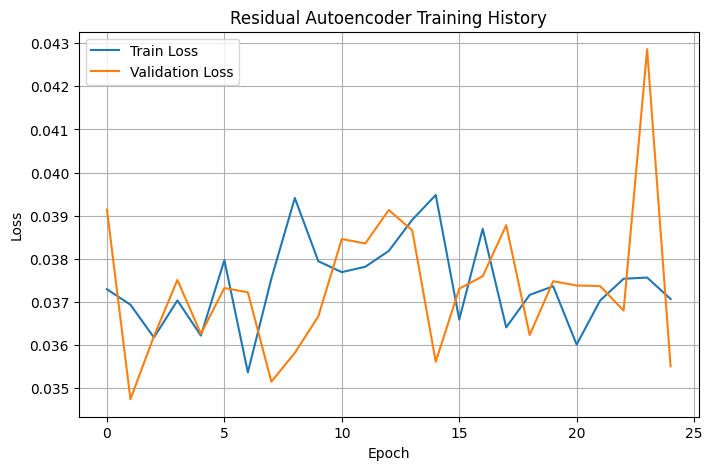

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_loss_history, label="Train Loss")
plt.plot(valid_loss_history, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Residual Autoencoder Training History")

plt.legend()

plt.grid(True)

plt.show()

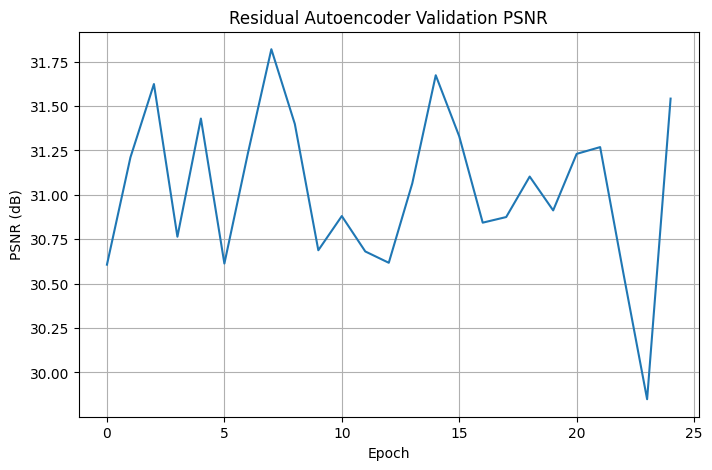

In [14]:
plt.figure(figsize=(8,5))

plt.plot(valid_psnr_history)

plt.xlabel("Epoch")
plt.ylabel("PSNR (dB)")
plt.title("Residual Autoencoder Validation PSNR")

plt.grid(True)

plt.show()

In [15]:
import json

history = {
    "train_loss": train_loss_history,
    "valid_loss": valid_loss_history,
    "valid_psnr": valid_psnr_history
}

with open("../results/metrics/autoencoder_residual_training_history.json", "w") as f:
    json.dump(history, f, indent=4)

print("Training history saved.")

Training history saved.


In [16]:
from src.checkpoint import save_model

save_model(
    model,
    "../results/checkpoints/autoencoder_residual_perceptual.pth"
)

print("Final model saved.")

Final model saved.


In [17]:
from src.checkpoint import load_model
from src.models.autoencoder_residual import ConvAutoencoderResidual

model = ConvAutoencoderResidual().to(device)

model = load_model(
    model,
    "../results/checkpoints/autoencoder_residual_perceptual.pth",
    device
)

print("Residual Autoencoder loaded successfully.")

Residual Autoencoder loaded successfully.


c:\Users\aless\Documents\RetroSR-CNN\src\checkpoint.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(filepath, map_location=device)
